

You will:
- Load **four tables** (`orders`, `order_items`, `order_shipping`, `payments`).
- Join them into a single order-level dataset.
- Clean and transform the data.
- Perform basic EDA and visualization.

Work **top-to-bottom**. Complete each sub-part in the order they appear before proceeding.

## Setup

Run the cell below to import the required Python packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

plt.style.use('seaborn-v0_8')

---
## Part 1: Data Preprocessing (10 marks)

### 1.1 Data Loading & Joining (4 marks)

We first load each table, inspect it, and then join them into a single DataFrame.


#### Load the CSV files

**Task:**
- Dowload the four CSV files from canvas and upload them under the 'files' tab for this colab instance
- Load the four CSV files using `pd.read_csv()` into:
  - `df_orders`
  - `df_order_items`
  - `df_shipping`
  - `df_payments`

Update the filenames/paths if necessary.

In [2]:
# ANSWER: load the CSV files

from google.colab import drive

# Update path as neccessary
# If using default, please upload CSVs to the "MyDrive" dir
# Otherwise, please amend, else it will fail
# Define the base directory where your CSV files are located.
path = "/content/drive/MyDrive/" # This should be the direct path to your dataset folder.
drive.mount('/content/drive')

try:
  # Use the 'path' variable directly as the base for reading the CSVs
  df_orders = pd.read_csv(f"{path}orders.csv")
  df_order_items = pd.read_csv(f"{path}order_items.csv")
  df_shipping = pd.read_csv(f"{path}order_shipping.csv")
  df_payments = pd.read_csv(f"{path}payments.csv")
  print("Files loaded")
except Exception as e:
  # Provide a more informative error message in case of failure
  print(f"Error loading files. Ensure directory '{path}' exists and contains the CSVs. Error: {e}")

Mounted at /content/drive
Files loaded


In [3]:
!jupyter nbconvert --to html "/content/drive/MyDrive/5100FProjSubmission/IT5100F_Assignment_1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/5100FProjSubmission/IT5100F_Assignment_1.ipynb to html
[NbConvertApp] Writing 356692 bytes to /content/drive/MyDrive/5100FProjSubmission/IT5100F_Assignment_1.html


#### Inspect each table

**Task:**
- For **each** DataFrame, display:
  - `head()` (first 5 rows)
  - `shape` (rows, columns)

This helps you understand the raw structure before joining.

In [4]:
# HELPER:
def header(name):
  print("\n" + "=" * 80)
  print(name)
  print("=" * 80)

# ANSWER: inspect the DataFrames
lst = [("orders",df_orders), ("order_items",df_order_items),("shipping", df_shipping), ("payments", df_payments)]

def inspect_df(name,df):
  header(name)
  print(df.head())
  print(f"\nShape: {df.shape}")

for name,df in lst:
  inspect_df(name,df)

  # order_id is the common


orders
        order_id order_status  order_purchase_hour  order_purchase_dayofweek  \
0  sdv-id-whzjUX      shipped                   10                         4   
1  sdv-id-gqShVM    delivered                   19                         2   
2  sdv-id-vtaqcY    delivered                   18                         4   
3  sdv-id-xkqwdo     invoiced                   23                         1   
4  sdv-id-sGyHvQ    delivered                   19                         0   

   order_purchase_month  order_total_value  
0                     4         744.312535  
1                     4        1030.521912  
2                     8          28.472994  
3                     8         143.914263  
4                     2          16.944537  

Shape: (100000, 6)

order_items
        order_id  num_items  num_unique_products  num_unique_sellers  \
0  sdv-id-whzjUX          1                    1                   1   
1  sdv-id-gqShVM          1                    1                

#### Join the tables on `order_id` to create a single order-level DataFrame

**Task:**
- Perform **inner joins** on `order_id` so that only orders present in **all** tables remain.
- Join order tables in this order:
  1. `df_orders` with `df_order_items`
  2. result with `df_shipping`
  3. result with `df_payments`
- Store the final DataFrame as `df_orders_full`.
- Display `head()` and `shape` for `df_orders_full`.


In [5]:
# ANSWER: join the tables
# 1.
df_orders_full = df_orders.merge(df_order_items, on='order_id', how='inner')
# 2.
df_orders_full = df_orders_full.merge(df_shipping, on='order_id', how='inner')
# 3.
df_orders_full = df_orders_full.merge(df_payments, on='order_id', how='inner')

# Check
header("df_orders_full - head:")
print(df_orders_full.head())
print(f"\nFinal shape: {df_orders_full.shape}")



df_orders_full - head:
        order_id order_status  order_purchase_hour  order_purchase_dayofweek  \
0  sdv-id-whzjUX      shipped                   10                         4   
1  sdv-id-gqShVM    delivered                   19                         2   
2  sdv-id-vtaqcY    delivered                   18                         4   
3  sdv-id-xkqwdo     invoiced                   23                         1   
4  sdv-id-sGyHvQ    delivered                   19                         0   

   order_purchase_month  order_total_value  num_items  num_unique_products  \
0                     4         744.312535          1                    1   
1                     4        1030.521912          1                    1   
2                     8          28.472994          1                    1   
3                     8         143.914263          1                    1   
4                     2          16.944537          1                    1   

   num_unique_sellers  tot

# Inner joins
An inner join as a common denominator/identifier ensures only orders with complete records across all four tables are retained, avoiding incomplete rows.

---
### 1.2 Data Cleaning (3 marks)

We now clean `df_orders_full` so it is ready for analysis.

#### Handle missing values

**Task:**
- For **numerical** columns: replace missing values with the **median** of that column.
- For **categorical** columns: replace missing values with the **mode** (most frequent value).
- Drop any rows where `order_id` or `payment_type` is missing (if any remain)

Work directly on `df_orders_full`.

In [6]:
# ANSWER: Handle missing values

before = len(df_orders_full)
print(f"\nBefore: {before}")

# Identify numerical and categorical columns
numerical_cols = df_orders_full.select_dtypes(include=[np.number]).columns
categorical_cols = df_orders_full.select_dtypes(include=['object']).columns

# Fill numerical columns with median
for col in numerical_cols:
    if df_orders_full[col].isnull().any():
        missing_before = df_orders_full[col].isnull().sum()
        median_value = df_orders_full[col].median()
        df_orders_full[col] = df_orders_full[col].fillna(median_value)
        pct = (missing_before / before) * 100
        print(f"{col}: filled {missing_before} missing values ({pct:.2f}%) with median = {median_value}")

# Fill categorical columns with mode
total_mode_added = 0

for col in categorical_cols:
    if df_orders_full[col].isnull().any():
        missing_before = df_orders_full[col].isnull().sum()
        mode_value = df_orders_full[col].mode(dropna=True)[0]
        df_orders_full[col] = df_orders_full[col].fillna(mode_value)

        total_mode_added += missing_before
        pct = (missing_before / before) * 100

        print(f"{col}: filled {missing_before} missing values ({pct:.2f}%) using mode = {mode_value}")

print(f"\nTotal mode values added across categorical columns: {total_mode_added}")

# Drop rows where order_id or payment_type is still missing
initial_count = len(df_orders_full)
df_orders_full = df_orders_full.dropna(subset=['order_id', 'payment_type'])
dropped_count = initial_count - len(df_orders_full)

print(f"\nRows dropped due to missing order_id or payment_type: {dropped_count}")
print(f"Total rows after handling missing values: {len(df_orders_full)}")

# Some pollution with modal/median, based on the calculated percentages 0.77% | 11.56% | 0.32%
# 11.56% is kind of risky, but we need to acknoledge this loss
# The best way would jsut be go back and collect data
# Alternatively, we can randomise and populate with top-K
# Or, with AI, we can predict the missing value based on a pre-trained data set, but this becomes a chicken and egg problem



Before: 100000
avg_item_price: filled 772 missing values (0.77%) with median = 86.65890841903718
top_product_category: filled 11556 missing values (11.56%) using mode = bed_bath_table
payment_type: filled 322 missing values (0.32%) using mode = credit_card

Total mode values added across categorical columns: 11878

Rows dropped due to missing order_id or payment_type: 0
Total rows after handling missing values: 100000


# Handle missing values
Median imputation is used for avg_item_price as it is robust to outliers. Mode imputation is used for categorical columns (top_product_category, payment_type) since the most frequent value is the best single-point estimate.

Note: top_product_category had 11.56% missing — this level of imputation may inflate bed_bath_table's frequency downstream.

#### Remove clearly invalid numeric records

**Task:**
- Remove rows where:
  - `num_items` ≤ 0, or
  - `order_total_value` ≤ 0, or
  - `total_item_price` < 0, or
  - `total_freight_value` < 0.


In [7]:
# ANSWER: filter invalid numeric records
before = len(df_orders_full)
df_orders_full = df_orders_full[
    (df_orders_full['num_items'] > 0) &
    (df_orders_full['order_total_value'] > 0) &
    (df_orders_full['total_item_price'] >= 0) &
    (df_orders_full['total_freight_value'] >= 0)
]
after = len(df_orders_full)
print("Rows after removing invalid records:", after)
print("Rows removed:", before - after, f"({(before - after) / before * 100:.2f}%)")

# Display summary statistics for the filtered columns
print("\nSummary statistics after filtering:")
print(df_orders_full[['num_items', 'order_total_value', 'total_item_price', 'total_freight_value']].describe())

# Acceptable row loss(?) ~ 10.82%

Rows after removing invalid records: 89175
Rows removed: 10825 (10.82%)

Summary statistics after filtering:
          num_items  order_total_value  total_item_price  total_freight_value
count  89175.000000       89175.000000      89175.000000         89175.000000
mean       1.635615         207.901833        181.373462            29.624502
std        1.264491         255.407688        260.402395            29.016850
min        1.000000           0.392487          0.000000             0.000000
25%        1.000000          70.430186         47.773916            14.432822
50%        1.000000         131.923056         98.593944            19.828603
75%        2.000000         226.124313        207.278599            34.466860
max        8.000000        2890.551922       2876.795389           278.425514


## Invalid records
Records with zero or negative num_items or order_total_value are logically impossible for a valid transaction and are removed to ensure data quality.

#### Check cleanliness and key uniqueness

**Task:**
- Confirm there are **no null values** in `df_orders_full`.
- Check that `order_id` is unique (one row per order).


In [8]:
# ANSWER: final cleaning checks
# Check for null values
null_counts = df_orders_full.isnull().sum()
print(f"\nTotal null values: {null_counts.sum()}")

# Check order_id uniqueness
print(f"Unique? {len(df_orders_full) == df_orders_full['order_id'].nunique()}")

# Check for duplicates
duplicates = df_orders_full.duplicated(subset=['order_id']).sum()
print(f"Number of duplicate order_id: {duplicates}")


Total null values: 0
Unique? True
Number of duplicate order_id: 0


---
### 1.3 Data Transformation (3 marks)

Next, we perform sanity checks and create new features that will be useful later.

#### Sanity checks on counts and values

**Task:**
- Keep only rows where both:
  - `num_items` ≥ `num_unique_products`,
  - `order_total_value` ≥ `total_item_price + total_freight_value`


In [9]:
# ANSWER: apply sanity checks
rows_before = len(df_orders_full)
print(f"Rows before sanity checks: {rows_before}")

# Check 1: num_items >= num_unique_products
check1 = df_orders_full['num_items'] >= df_orders_full['num_unique_products']
print(f"Rows failing check (num_items >= num_unique_products): {(~check1).sum()}")

# Check 2: order_total_value >= total_item_price + total_freight_value
check2 = df_orders_full['order_total_value'] >= (
    df_orders_full['total_item_price'] + df_orders_full['total_freight_value']
)
print(f"Rows failing check (order_total_value >= total_item_price + total_freight_value): {(~check2).sum()}")

# Apply both sanity checks
df_orders_full = df_orders_full[check1 & check2]

rows_after = len(df_orders_full)
print(f"\nRows after sanity checks: {rows_after}")
print(f"\nRows lost: {rows_before - rows_after} ({(rows_before - rows_after) / rows_before:.2%}))")

# 48.09% doesnt seem good, but it might be due to messy data input


Rows before sanity checks: 89175
Rows failing check (num_items >= num_unique_products): 1370
Rows failing check (order_total_value >= total_item_price + total_freight_value): 42220

Rows after sanity checks: 46287

Rows lost: 42888 (48.09%))


## Sanity Check
These checks enforce 2 rules: an order cannot have more unique products than items, and the total order value must cover item price plus freight. Rows failing these checks likely reflect data entry errors, meaning code above is wrong.

#### Create `order_value_per_item`

**Task:**
- Create a new column `order_value_per_item` defined as `total_item_price / num_items`.


In [10]:
# ANSWER: create order_value_per_item
df_orders_full['order_value_per_item'] = df_orders_full['total_item_price'] / df_orders_full['num_items']

print("Order_value_per_item:")
print(df_orders_full[['order_id', 'total_item_price', 'num_items', 'order_value_per_item']].head())
print("\nSummary:")
print(df_orders_full['order_value_per_item'].describe())

Order_value_per_item:
         order_id  total_item_price  num_items  order_value_per_item
0   sdv-id-whzjUX        352.420029          1            352.420029
5   sdv-id-dbopoJ        289.242639          1            289.242639
8   sdv-id-FSEOvM         26.893468          1             26.893468
12  sdv-id-bQcBUR         37.790896          1             37.790896
14  sdv-id-MPxIXB        169.528323          3             56.509441

Summary:
count    46287.000000
mean        87.741952
std        123.271289
min          0.000000
25%         32.092891
50%         56.494847
75%         99.747557
max       2606.843945
Name: order_value_per_item, dtype: float64


#### Create `order_size_category`

**Task:**
- Create a new categorical column `order_size_category` with values:
  - "Small" if `num_items` ≤ 2
  - "Medium" if `num_items` ≤ 5
  - "Large" if `num_items` > 5


In [11]:
# ANSWER: create order_size_category
# Make bins
# 0 <-x1-> 2 <-x2-> 5 <-x3-> np.inf
bins = [0, 2, 5, np.inf]
labels = ["Small", "Medium", "Large"]

df_orders_full['order_size_category'] = pd.cut(
    df_orders_full['num_items'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

sample_rows = pd.concat([
    df_orders_full[['order_id', 'num_items', 'order_size_category']].head(10),
    df_orders_full[['order_id', 'num_items', 'order_size_category']].tail(10)
])

print("Sample values:")
sample_rows

Sample values:


,order_id,num_items,order_size_category
0,sdv-id-whzjUX,1,Small
5,sdv-id-dbopoJ,1,Small
8,sdv-id-FSEOvM,1,Small
12,sdv-id-bQcBUR,1,Small
14,sdv-id-MPxIXB,3,Medium
15,sdv-id-ySodbB,7,Large
17,sdv-id-wdwBrk,2,Small
18,sdv-id-maBYtk,3,Medium
19,sdv-id-oodUXj,1,Small
20,sdv-id-zroJIL,1,Small


#### Final transformation check

**Task:**
- Confirm there are no null values in `df_orders_full`.
- Display:
  - `head()`
  - `shape`
  - `info()`


In [12]:
# ANSWER: final transformation summary
print("Checking for null values:")
print(df_orders_full.isnull().sum())
print(f"\nTotal null values: {df_orders_full.isnull().sum().sum()}")

# Display first 5 rows
header("First 5 rows of df_orders_full:")
print(df_orders_full.head())

# Display shape
header("Shape:")
print(f"Rows: {df_orders_full.shape[0]}, Columns: {df_orders_full.shape[1]}")
print(df_orders_full.shape)

# Display info (data types)
header("Data types and info:")
print(df_orders_full.info())

Checking for null values:
order_id                    0
order_status                0
order_purchase_hour         0
order_purchase_dayofweek    0
order_purchase_month        0
order_total_value           0
num_items                   0
num_unique_products         0
num_unique_sellers          0
total_item_price            0
avg_item_price              0
total_freight_value         0
top_product_category        0
customer_state              0
payment_type                0
order_value_per_item        0
order_size_category         0
dtype: int64

Total null values: 0

First 5 rows of df_orders_full:
         order_id order_status  order_purchase_hour  order_purchase_dayofweek  \
0   sdv-id-whzjUX      shipped                   10                         4   
5   sdv-id-dbopoJ    delivered                   19                         2   
8   sdv-id-FSEOvM    delivered                   15                         4   
12  sdv-id-bQcBUR    delivered                   21                     

### 1.4 Data Storage

We now save the cleaned, joined, and transformed dataset.

#### 1.4A Save cleaned dataset

**Task:**
- Save `df_orders_full` as `ecommerce_orders_cleaned.csv` (without the index).

In [13]:
# ANSWER: save to CSV
cleaned_file_to_save_as = 'ecommerce_orders_cleaned_Grp11.csv'
df_orders_full.to_csv(f'/content/drive/MyDrive/{cleaned_file_to_save_as}', index=False)
print(f"Successfully saved df_orders_full to {cleaned_file_to_save_as}")
print("Shape:", df_orders_full.shape)

Successfully saved df_orders_full to ecommerce_orders_cleaned_Grp11.csv
Shape: (46287, 17)


---
## Part 2: EDA & Data Visualization (4 marks)

We now reload the cleaned dataset and explore it.

### 2.0 Load Transformed Dataset

#### 2.0 Reload CSV

**Task:**
- Load `ecommerce_orders_cleaned.csv` into `df_orders_cleaned`.
- Display `head()` and `shape`.

In [14]:
# ANSWER: load cleaned dataset
df_orders_cleaned = pd.read_csv(f'/content/drive/MyDrive/{cleaned_file_to_save_as}')
header("First 5 rows:")
print(df_orders_cleaned.head())
print(f"\nShape: {df_orders_cleaned.shape}")


First 5 rows:
        order_id order_status  order_purchase_hour  order_purchase_dayofweek  \
0  sdv-id-whzjUX      shipped                   10                         4   
1  sdv-id-dbopoJ    delivered                   19                         2   
2  sdv-id-FSEOvM    delivered                   15                         4   
3  sdv-id-bQcBUR    delivered                   21                         0   
4  sdv-id-MPxIXB    delivered                   13                         5   

   order_purchase_month  order_total_value  num_items  num_unique_products  \
0                     4         744.312535          1                    1   
1                     3        1556.667902          1                    1   
2                     8          62.060506          1                    1   
3                     8          73.873470          1                    1   
4                     5         361.961537          3                    3   

   num_unique_sellers  total_item_p

### 2.1 Unique Categories and Payment Types (1 mark)

**Task:**
- Compute the number of unique values in `top_product_category` and `payment_type`.
- Display:
  - The top 5 product categories by order count.
  - The top 3 payment types by order count.

In [15]:
# ANSWER: unique counts and top values
num_unique_categories = df_orders_cleaned['top_product_category'].nunique()
num_unique_payment_types = df_orders_cleaned['payment_type'].nunique()

print(f"Number of unique product categories: {num_unique_categories}")
print(f"Number of unique payment types: {num_unique_payment_types}")

# Uses .head() to chear out top-K values
# Uses .value_counts() to get unique order count
header("Top 5 most frequent product categories:")
print(df_orders_cleaned['top_product_category'].value_counts().head(5))

header("Top 3 most frequent payment types:")
print(df_orders_cleaned['payment_type'].value_counts().head(3))

Number of unique product categories: 71
Number of unique payment types: 5

Top 5 most frequent product categories:
top_product_category
bed_bath_table           6419
health_beauty            4208
furniture_decor          3413
computers_accessories    3386
telephony                2570
Name: count, dtype: int64

Top 3 most frequent payment types:
payment_type
credit_card    27987
voucher        13812
points          2532
Name: count, dtype: int64


### 2.2 Bar Chart of Orders by Product Category (2 marks)

#### Create bar chart

**Task:**
- Create a bar chart of number of orders per `top_product_category`, sorted in descending order.
- Add a clear title and axis labels.

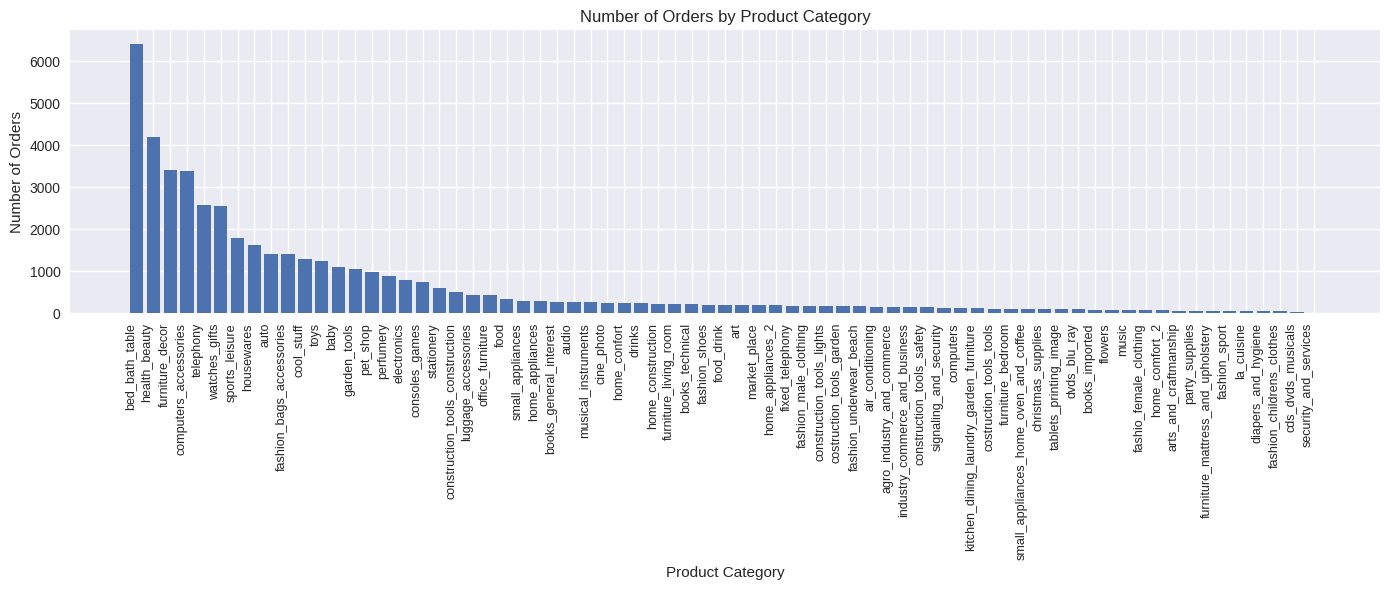

Total number of product categories: 71


In [16]:
# ANSWER: bar chart of product categories
# Count orders by product category and sort in descending order
category_counts = df_orders_cleaned['top_product_category'].value_counts().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(14, 6))
plt.bar(range(len(category_counts)), category_counts.values)
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Product Category')
plt.xticks(range(len(category_counts)), category_counts.index, rotation=90, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total number of product categories: {len(category_counts)}")

#### Brief interpretation

**Task:**
- In 2–3 sentences, describe any trends you see (e.g., which categories dominate, whether the distribution is skewed, etc.).


**Observations**

1) The top 5 product categories (bed_bath_table, health_beauty, furniture_decor, computers_accessories, telephony) dominate about 43.3% of all the orders, while the remaining 66 categories split the leftover 56.7%.

2) Most other categories have significantly fewer orders, indicating that customer demand is concentrated in a few popular product types rather than evenly spread across all categories.

3) Notably, bed_bath_table alone represents 13.9% of orders (6,419), which may be partially inflated since 11.56% of originally missing category values were imputed with this mode during data cleaning.

### 2.3 Box Plot: Order Value vs Number of Items (2 mark)

#### Create box plot

**Task:**
- Create a box plot with:
  - X‑axis: `num_items`
  - Y‑axis: `order_total_value`
- Add a clear title and axis labels.

<Figure size 1400x600 with 0 Axes>

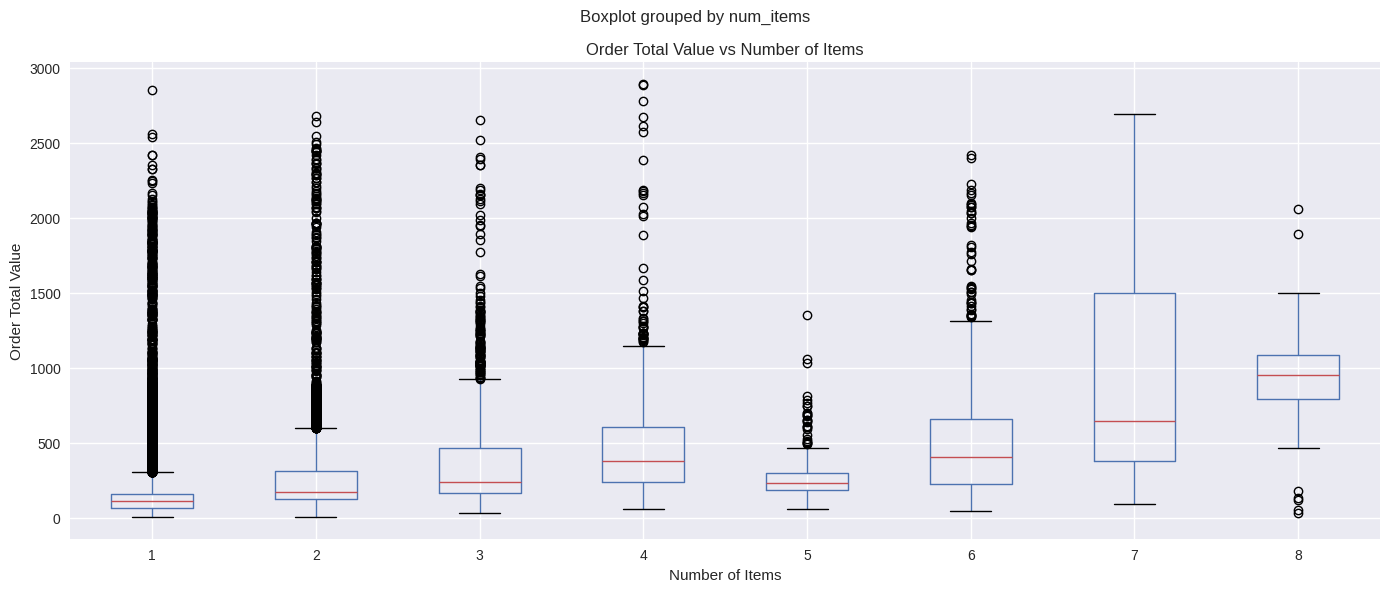


Summary statistics by num_items:
             count        mean         std        min         25%         50%  \
num_items                                                                       
1          33030.0  153.957758  188.044755   7.221685   64.615034  112.998665   
2           6996.0  278.559745  297.345362   6.116141  126.197219  175.905392   
3           2712.0  356.552470  303.395485  34.623184  164.038968  237.044482   
4           1584.0  462.992485  324.206979  59.857521  237.996542  381.802463   
5            247.0  284.750925  177.133467  60.995091  187.660277  232.955564   
6           1048.0  501.951377  377.567673  47.866393  223.419962  403.951652   
7            520.0  927.035616  672.093645  90.983967  381.796148  646.512643   
8            150.0  936.066533  279.451044  34.803172  792.405180  952.014953   

                   75%          max  
num_items                            
1           161.132292  2852.653375  
2           315.905431  2679.152604  
3  

In [17]:
# ANSWER: box plot order_total_value vs num_items
# Create the box plot
plt.figure(figsize=(14, 6))
df_orders_cleaned.boxplot(column='order_total_value', by='num_items', figsize=(14, 6))
plt.xlabel('Number of Items')
plt.ylabel('Order Total Value')
plt.title('Order Total Value vs Number of Items')
plt.tight_layout()
plt.show()

# Display summary statistics
print("\nSummary statistics by num_items:")
print(df_orders_cleaned.groupby('num_items')['order_total_value'].describe())

#### Brief interpretation

**Task:**
- In 2–3 sentences, describe how order value changes as the number of items increases (e.g., linear trend, diminishing returns, many outliers, etc.).

**Observations**

1) Order total value generally increases as the number of items increases, indicating a positive relationship between order size and total spending.

2) However, the presence of many outliers and increasing spread for higher item counts suggests substantial variability in prices, meaning larger orders do not always translate to proportionally higher total values.

3) Outliers appear across all item counts but are most prominent in single-item orders, suggesting high-value individual products can match or exceed multi-item order totals.

<!-- **Note from lecture**:
1. use Elbow(?) method to iteratively figure out clusters - data catagorizing
2. Save transformed data into a new dataframe, so we dont lose the original -->